In [1]:
import kagglehub
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.


In [2]:
print(path)

/kaggle/input/microsoft-catsvsdogs-dataset


In [ ]:
!ls -R /kaggle/input/microsoft-catsvsdogs-dataset/PetImages

/kaggle/input/microsoft-catsvsdogs-dataset:
'MSR-LA - 3467.docx'   PetImages  'readme[1].txt'

/kaggle/input/microsoft-catsvsdogs-dataset/PetImages:
Cat  Dog

/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat:
0.jpg	   11608.jpg  1966.jpg	3573.jpg  5180.jpg  6789.jpg  8396.jpg
10000.jpg  11609.jpg  1967.jpg	3574.jpg  5181.jpg  678.jpg   8397.jpg
10001.jpg  1160.jpg   1968.jpg	3575.jpg  5182.jpg  6790.jpg  8398.jpg
10002.jpg  11610.jpg  1969.jpg	3576.jpg  5183.jpg  6791.jpg  8399.jpg
10003.jpg  11611.jpg  196.jpg	3577.jpg  5184.jpg  6792.jpg  839.jpg
10004.jpg  11612.jpg  1970.jpg	3578.jpg  5185.jpg  6793.jpg  83.jpg
10005.jpg  11613.jpg  1971.jpg	3579.jpg  5186.jpg  6794.jpg  8400.jpg
10006.jpg  11614.jpg  1972.jpg	357.jpg   5187.jpg  6795.jpg  8401.jpg
10007.jpg  11615.jpg  1973.jpg	3580.jpg  5188.jpg  6796.jpg  8402.jpg
10008.jpg  11616.jpg  1974.jpg	3581.jpg  5189.jpg  6797.jpg  8403.jpg
10009.jpg  11617.jpg  1975.jpg	3582.jpg  518.jpg   6798.jpg  8404.jpg
1000.jpg   11618.jp

In [ ]:
!mkdir -p /content/PetImages
!cp -r /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/* /content/PetImages/


In [11]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from keras.layers import Dense , Conv2D , MaxPooling2D , Flatten , BatchNormalization , Dropout
from PIL import Image


In [6]:
data_dir = "/content/cleaned_dataset"   # folder that contains "cat" and "dog"

In [5]:
from PIL import Image
import os

clean_dir = "cleaned_dataset"

os.makedirs(clean_dir, exist_ok=True)

for label in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, label)
    if not os.path.isdir(class_dir):
        continue

    clean_class_dir = os.path.join(clean_dir, label)
    os.makedirs(clean_class_dir, exist_ok=True)

    for file in os.listdir(class_dir):
        file_path = os.path.join(class_dir, file)
        try:
            img = Image.open(file_path).convert("RGB")  # convert any image to RGB
            img.save(os.path.join(clean_class_dir, file))
        except:
            print(f"Skipping corrupted image: {file_path}")


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Skipping corrupted image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/11702.jpg
Skipping corrupted image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog/Thumbs.db
Skipping corrupted image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/Thumbs.db
Skipping corrupted image: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat/666.jpg


In [7]:
from PIL import Image
import os

print("Cleaning invalid images...")

for label in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, label)
    if not os.path.isdir(class_dir):
        continue

    for file in os.listdir(class_dir):
        file_path = os.path.join(class_dir, file)
        try:
            img = Image.open(file_path)
            img.verify()  # check for corruption

            # Re-open to check mode
            img = Image.open(file_path)
            if img.mode not in ["L", "RGB", "RGBA"]:
                print(f"Removing image with unsupported channels ({img.mode}): {file_path}")
                os.remove(file_path)

        except Exception as e:
            print(f"Removing corrupted image: {file_path}")
            os.remove(file_path)


Cleaning invalid images...


In [8]:
# import tensorflow as tf
# import numpy as np

batch_size = 32
img_size = (256, 256)
validation_split = 0.2
seed = 42

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",  # or "grayscale" if you want 2D arrays
    batch_size=batch_size,
    image_size=img_size,
    shuffle=True,
    seed=seed,
    validation_split=validation_split,
    subset="training"
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",  # or "grayscale"
    batch_size=batch_size,
    image_size=img_size,
    shuffle=True,
    seed=seed,
    validation_split=validation_split,
    subset="validation"
)




Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [ ]:
train_ds.file_paths

['/content/PetImages/Cat/493.jpg',
 '/content/PetImages/Dog/8119.jpg',
 '/content/PetImages/Cat/7450.jpg',
 '/content/PetImages/Dog/11021.jpg',
 '/content/PetImages/Dog/8503.jpg',
 '/content/PetImages/Cat/5488.jpg',
 '/content/PetImages/Cat/3972.jpg',
 '/content/PetImages/Dog/10365.jpg',
 '/content/PetImages/Cat/1796.jpg',
 '/content/PetImages/Cat/736.jpg',
 '/content/PetImages/Dog/678.jpg',
 '/content/PetImages/Cat/1900.jpg',
 '/content/PetImages/Cat/474.jpg',
 '/content/PetImages/Dog/10499.jpg',
 '/content/PetImages/Cat/12263.jpg',
 '/content/PetImages/Dog/10772.jpg',
 '/content/PetImages/Dog/652.jpg',
 '/content/PetImages/Dog/6470.jpg',
 '/content/PetImages/Cat/4591.jpg',
 '/content/PetImages/Cat/4950.jpg',
 '/content/PetImages/Cat/5725.jpg',
 '/content/PetImages/Cat/6500.jpg',
 '/content/PetImages/Cat/4732.jpg',
 '/content/PetImages/Cat/12000.jpg',
 '/content/PetImages/Cat/9603.jpg',
 '/content/PetImages/Dog/8517.jpg',
 '/content/PetImages/Cat/7409.jpg',
 '/content/PetImages/Dog/38

In [9]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)  # Normalize image values to [0, 1] range
    return image, label

# Apply the process function to the training and validation datasets
train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

First image shape: (256, 256, 3)
First image pixel data (first 10 values): [0.6683626  0.3311077  0.57816654 0.6281939  0.29093903 0.53799784
 0.6370132  0.29975832 0.5468171  0.602757  ]


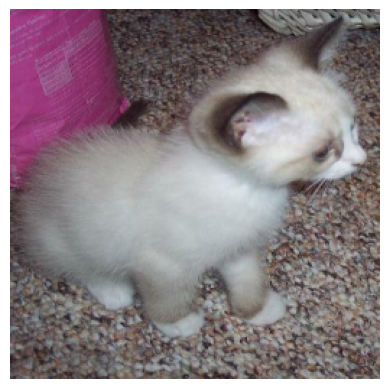

In [10]:
# Fetch the first batch of images and labels
for batch_images, batch_labels in train_ds.take(1):  # take(1) ensures only the first batch
    # Extract the first image from the batch
    first_image = batch_images[0].numpy()  # Convert the first image to a NumPy array

    # Print the shape and the first few values (optional)
    print(f"First image shape: {first_image.shape}")
    print(f"First image pixel data (first 10 values): {first_image.flatten()[:10]}")

    # If you want to visualize the first image:
    import matplotlib.pyplot as plt
    plt.imshow(first_image)  # Values should be between 0 and 1 after normalization
    plt.axis('off')  # Hide axis for better visualization
    plt.show()

    break  # Exit after processing the first batch


In [26]:
model = Sequential()

model.add(Conv2D(128 , kernel_size=(3,3) , padding = 'valid' , activation = 'relu' , input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'valid'))

model.add(Conv2D(256 , kernel_size=(3,3) , padding = 'valid' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'valid'))

model.add(Conv2D(128 , kernel_size=(3,3) , padding = 'valid' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'valid'))

model.add(Conv2D(64 , kernel_size=(3,3) , padding = 'valid' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2) , strides = 2 , padding = 'valid'))

model.add(Flatten())

model.add(Dense(128 , activation='relu' , kernel_regularizer=keras.regularizers.l2(0.005)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(64 , activation='relu' , kernel_regularizer=keras.regularizers.l2(0.005)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(50 , activation='relu' , kernel_regularizer=keras.regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(1 , activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 254, 254, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 125, 125, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,288,173 (8.73 MB)

 Trainable params: 2,286,537 (8.72 MB)

 Non-trainable params: 1,636 (6.39 KB)

In [33]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)  , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [ ]:
history = model.fit(train_ds , epochs = 35 , validation_data = val_ds)

Epoch 1/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 224s 342ms/step - accuracy: 0.9708 - loss: 0.2560 - val_accuracy: 0.9416 - val_loss: 0.2585
Epoch 2/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 332ms/step - accuracy: 0.9817 - loss: 0.1424 - val_accuracy: 0.9418 - val_loss: 0.2671
Epoch 3/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.9873 - loss: 0.1123 - val_accuracy: 0.9412 - val_loss: 0.2732
Epoch 4/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.9899 - loss: 0.1035 - val_accuracy: 0.9442 - val_loss: 0.2666
Epoch 5/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.9938 - loss: 0.0879 - val_accuracy: 0.9412 - val_loss: 0.2780
Epoch 6/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.9930 - loss: 0.0890 - val_accuracy: 0.9422 - val_loss: 0.2714
Epoch 7/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.9955 - loss: 0.0732 - val_accuracy: 0.9434 - val_loss: 0.2709
Epoch 8/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 208s 332ms/step - accuracy: 0.9965 -

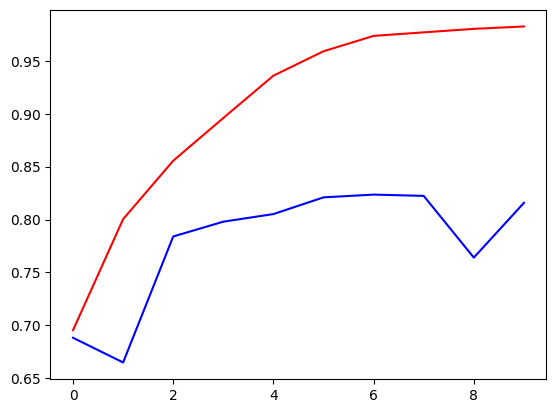

In [16]:
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'validation')

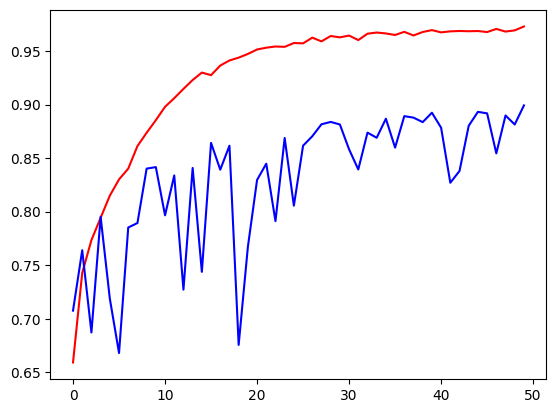

In [24]:
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'validation')

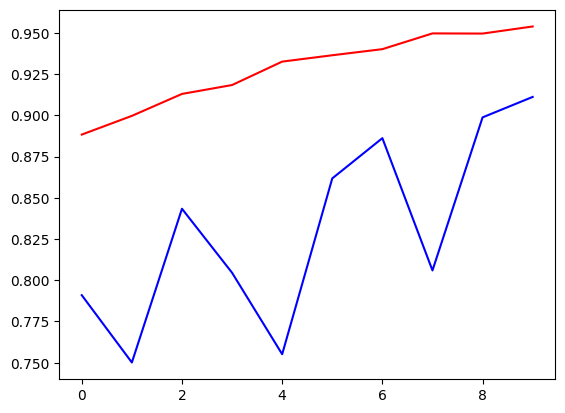

In [31]:
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'validation')

In [ ]:
plt.plot(history.history['accuracy'] , color = 'red' , label = 'train')
plt.plot(history.history['val_accuracy'] , color = 'blue' , label = 'validation')

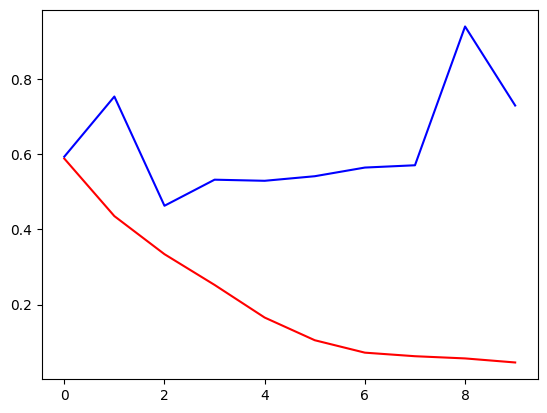

In [17]:
plt.plot(history.history['loss'] , color = 'red' , label = 'train')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'validation')

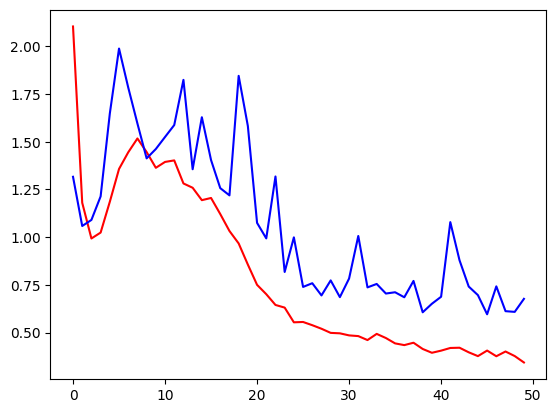

In [25]:
plt.plot(history.history['loss'] , color = 'red' , label = 'train')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'validation')

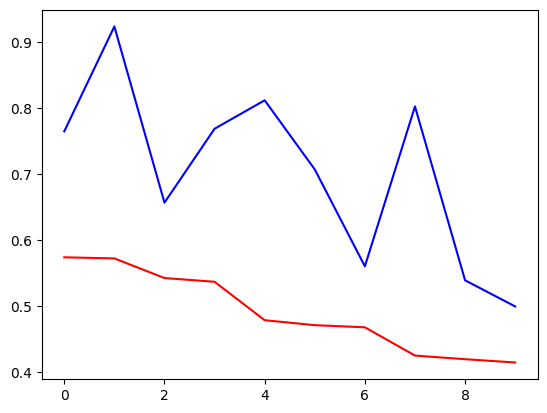

In [32]:
plt.plot(history.history['loss'] , color = 'red' , label = 'train')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'validation')

In [ ]:
plt.plot(history.history['loss'] , color = 'red' , label = 'train')
plt.plot(history.history['val_loss'] , color = 'blue' , label = 'validation')